# MoLE-DLinear Multivariate Forecasting — lon / lat / alt

This notebook trains the **official MoLE-DLinear** model from the paper
[*Mixture-of-Linear-Experts for Long-term Time Series Forecasting*](https://arxiv.org/abs/2312.06786)
(AISTATS 2024) on the `italy_flights_20k` dataset.

The model code is taken **directly** from the official repository:
[https://github.com/RogerNi/MoLE](https://github.com/RogerNi/MoLE)
(cloned into `MoLE-git/` in this directory).

- **Input (context):** 60 time-steps of `[lon, lat, alt]` (~10 min at 10 s spacing)
- **Output (forecast):** next 12 time-steps of `[lon, lat, alt]` (~2 min)
- Flights with fewer than 200 observations are dropped.
- Per-flight `StandardScaler` is applied before training.
- Train / test split: 70 % / 30 % per flight.

## 0. Imports

In [63]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Point Python at the official MoLE repo ──────────────────────────────────
# Notebooks run with CWD = Forecasting_Baseline/
MOLE_REPO = os.path.abspath('MoLE-git')
if MOLE_REPO not in sys.path:
    sys.path.insert(0, MOLE_REPO)

# ── Import the official MoLE-DLinear model ───────────────────────────────────
from models.MoLE_DLinear import Model as MoLE_DLinear  # official code

print('MoLE-DLinear imported from:', MOLE_REPO)
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print('Device:', device)

MoLE-DLinear imported from: /Users/mayaeidelman/Documents/tahoe-research/Forecasting_Baseline/MoLE-git
Device: mps


## 1. Load data

In [64]:
df = pd.read_parquet('../data/italy_flights_20k.parquet')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

print(f'Total rows: {len(df):,}')
print(f'Unique flights: {df["track_id"].nunique():,}')
df.head()

Total rows: 2,493,533
Unique flights: 13,919


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30


## 2. Build per-flight arrays

In [65]:
MIN_LENGTH = 200   # drop flights shorter than this
FEATURES   = ['lon', 'lat', 'alt']

flights_data = []   # list of (values_array, timestamps_array)
skipped = 0

for track_id, g in df.groupby('track_id'):
    g = g.sort_values('datetime').drop_duplicates(subset='datetime')

    if len(g) < MIN_LENGTH:
        skipped += 1
        continue

    vals = g[FEATURES].values.astype(np.float32)   # [T, 3]
    ts   = g['datetime'].values                    # [T] datetime64

    if np.isnan(vals).any():
        skipped += 1
        continue

    flights_data.append((vals, ts))

print(f'Kept: {len(flights_data)} flights  |  Skipped: {skipped}')

Kept: 5828 flights  |  Skipped: 8091


## 3. Scale & split

In [66]:
TRAIN_FRAC = 0.7

train_flights = []   # list of (scaled_values, timestamps)
test_flights  = []   # list of (scaled_values, timestamps)
scalers       = []

for vals, ts in flights_data:
    split = int(len(vals) * TRAIN_FRAC)

    train_vals = vals[:split]
    test_vals  = vals[split:]
    train_ts   = ts[:split]
    test_ts    = ts[split:]

    scaler = StandardScaler()
    train_sc = scaler.fit_transform(train_vals)
    test_sc  = scaler.transform(test_vals)

    train_flights.append((train_sc.astype(np.float32), train_ts))
    test_flights.append((test_sc.astype(np.float32),  test_ts))
    scalers.append(scaler)

print(f'Train flights: {len(train_flights)}  |  Test flights: {len(test_flights)}')

Train flights: 5828  |  Test flights: 5828


## 4. Build temporal features (`x_mark`)

The official MoLE model uses the **temporal embedding of the first input timestep**
to learn gating weights. We encode 5 temporal features (for non-hourly data):

| Feature | Range | Normalised to |
|---------|-------|---------------|
| second-of-minute | 0–59 | [−0.5, 0.5] |
| minute-of-hour | 0–59 | [−0.5, 0.5] |
| hour-of-day | 0–23 | [−0.5, 0.5] |
| day-of-week | 0–6 | [−0.5, 0.5] |
| day-of-month | 1–31 | [−0.5, 0.5] |

In [67]:
def make_time_features(ts_array):
    """Convert a numpy array of datetime64 to a float32 array of shape [T, 5].
    Each column is normalised to [-0.5, 0.5].
    Columns: second/60, minute/60, hour/24, weekday/7, day/31
    """
    ts = pd.DatetimeIndex(ts_array)
    feats = np.stack([
        ts.second      / 60.0  - 0.5,
        ts.minute      / 60.0  - 0.5,
        ts.hour        / 24.0  - 0.5,
        ts.dayofweek   / 7.0   - 0.5,
        ts.day         / 31.0  - 0.5,
    ], axis=1).astype(np.float32)
    return feats   # [T, 5]

## 5. Build sliding-window dataset

In [68]:
INPUT_LEN  = 60   # seq_len
OUTPUT_LEN = 12   # pred_len
WINDOW     = INPUT_LEN + OUTPUT_LEN

def build_windows(flights):
    """Return (X, X_mark, Y) tensors from a list of (scaled_vals, timestamps)."""
    xs, xmarks, ys = [], [], []
    for vals, ts in flights:
        marks = make_time_features(ts)   # [T, 5]
        T = len(vals)
        for start in range(0, T - WINDOW + 1):
            end_in  = start + INPUT_LEN
            end_out = start + WINDOW
            xs.append(vals[start:end_in])       # [INPUT_LEN, 3]
            xmarks.append(marks[start:end_in])  # [INPUT_LEN, 5]
            ys.append(vals[end_in:end_out])      # [OUTPUT_LEN, 3]
    X      = torch.tensor(np.stack(xs),      dtype=torch.float32)
    X_mark = torch.tensor(np.stack(xmarks),  dtype=torch.float32)
    Y      = torch.tensor(np.stack(ys),      dtype=torch.float32)
    return X, X_mark, Y

print('Building training windows...')
X_train, Xm_train, Y_train = build_windows(train_flights)
print(f'Train windows: {X_train.shape[0]:,}   X={X_train.shape}  Y={Y_train.shape}')

print('Building test windows...')
X_test,  Xm_test,  Y_test  = build_windows(test_flights)
print(f'Test  windows: {X_test.shape[0]:,}   X={X_test.shape}  Y={Y_test.shape}')

Building training windows...
Train windows: 760,038   X=torch.Size([760038, 60, 3])  Y=torch.Size([760038, 12, 3])
Building test windows...
Test  windows: 100,103   X=torch.Size([100103, 60, 3])  Y=torch.Size([100103, 12, 3])


## 6. Instantiate the official MoLE-DLinear model

In [69]:
class Configs:
    """Minimal config object accepted by the official MoLE_DLinear.Model."""
    seq_len      = INPUT_LEN   # 60
    pred_len     = OUTPUT_LEN  # 12
    enc_in       = 3           # lon, lat, alt
    t_dim        = 4           # number of MoLE expert heads
    freq         = '10s'       # non-hourly  ->  expected_time_features = 5
    individual   = False       # shared linear layers across channels
    head_dropout = 0.1

configs = Configs()
model   = MoLE_DLinear(configs).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MoLE-DLinear trainable parameters: {n_params:,}')

MoLE-DLinear trainable parameters: 6,084


## 7. Train the model

In [70]:
N_EPOCHS   = 10
BATCH_SIZE = 64
LR         = 1e-3

train_loader = DataLoader(
    TensorDataset(X_train, Xm_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for xb, xmb, yb in train_loader:
        xb  = xb.to(device)
        xmb = xmb.to(device)
        yb  = yb.to(device)

        pred = model(xb, xmb)   # [B, OUTPUT_LEN, 3]
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    avg = epoch_loss / len(X_train)
    print(f'Epoch {epoch:02d}/{N_EPOCHS}  train_loss={avg:.6f}')

print('Training complete.')

Epoch 01/10  train_loss=0.189809
Epoch 02/10  train_loss=0.187044
Epoch 03/10  train_loss=0.186890
Epoch 04/10  train_loss=0.186832
Epoch 05/10  train_loss=0.186860
Epoch 06/10  train_loss=0.186776
Epoch 07/10  train_loss=0.186784
Epoch 08/10  train_loss=0.186834
Epoch 09/10  train_loss=0.186817
Epoch 10/10  train_loss=0.186816
Training complete.


## 8. Evaluate on test set

In [71]:
test_loader = DataLoader(
    TensorDataset(X_test, Xm_test, Y_test),
    batch_size=512,
    shuffle=False,
)

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, xmb, yb in test_loader:
        xb  = xb.to(device)
        xmb = xmb.to(device)
        pred = model(xb, xmb).cpu()
        all_preds.append(pred)
        all_true.append(yb)

all_preds = torch.cat(all_preds)   # [N, OUTPUT_LEN, 3]
all_true  = torch.cat(all_true)

mse_val = ((all_preds - all_true) ** 2).mean().item()
mae_val = (all_preds - all_true).abs().mean().item()

print(f'Test MSE: {mse_val:.6f}')
print(f'Test MAE: {mae_val:.6f}')

Test MSE: 40016.242188
Test MAE: 9.001844


## 9. Per-feature time-series plot

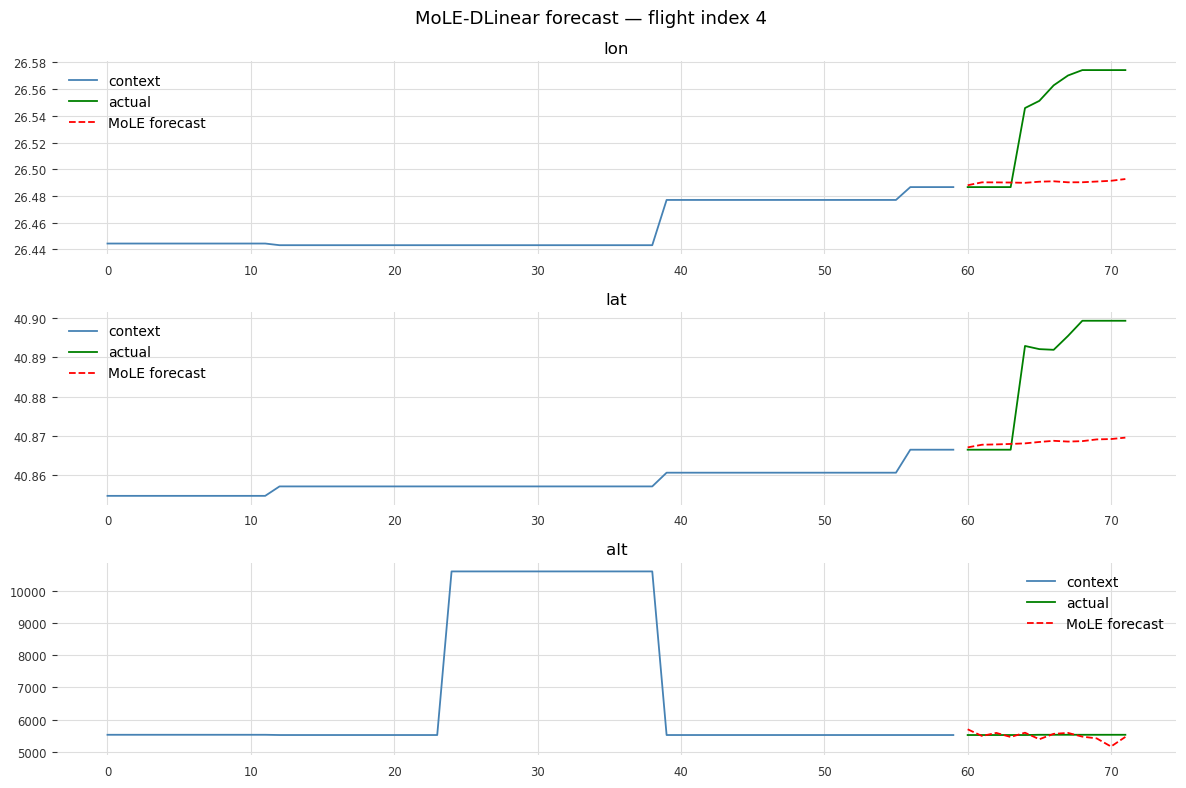

In [80]:
SAMPLE_IDX = 4   # change to inspect a different flight

# ── pick one flight from the test set ───────────────────────────────────────
test_vals, test_ts = test_flights[SAMPLE_IDX]
scaler             = scalers[SAMPLE_IDX]

# Use the first INPUT_LEN steps of the test split as context
ctx_sc   = test_vals[:INPUT_LEN]                          # scaled  [INPUT_LEN, 3]
act_sc   = test_vals[INPUT_LEN:INPUT_LEN + OUTPUT_LEN]   # scaled actual
ctx_ts   = test_ts[:INPUT_LEN]

if len(act_sc) < OUTPUT_LEN:
    raise ValueError('Flight too short for a full output window; try a different SAMPLE_IDX.')

# ── build x_mark for the context window ─────────────────────────────────────
ctx_mark = make_time_features(ctx_ts)      # [INPUT_LEN, 5]

xb  = torch.tensor(ctx_sc[np.newaxis],   dtype=torch.float32).to(device)
xmb = torch.tensor(ctx_mark[np.newaxis], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    fct_sc = model(xb, xmb).cpu().numpy()[0]   # [OUTPUT_LEN, 3]

# ── inverse-transform back to original units ────────────────────────────────
ctx_orig = scaler.inverse_transform(ctx_sc)
act_orig = scaler.inverse_transform(act_sc)
fct_orig = scaler.inverse_transform(fct_sc)

# ── build simple x-axes (step indices) ──────────────────────────────────────
ctx_x = np.arange(INPUT_LEN)
act_x = np.arange(INPUT_LEN, INPUT_LEN + OUTPUT_LEN)

feature_names = ['lon', 'lat', 'alt']
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, (ax, feat) in enumerate(zip(axes, feature_names)):
    ax.plot(ctx_x, ctx_orig[:, i],  color='steelblue', label='context')
    ax.plot(act_x, act_orig[:, i],  color='green',     label='actual')
    ax.plot(act_x, fct_orig[:, i],  color='red', linestyle='--',
            label='MoLE forecast')
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f'MoLE-DLinear forecast — flight index {SAMPLE_IDX}', fontsize=13)
plt.tight_layout()
plt.show()

## 10. 2-D trajectory plot (lon vs lat)

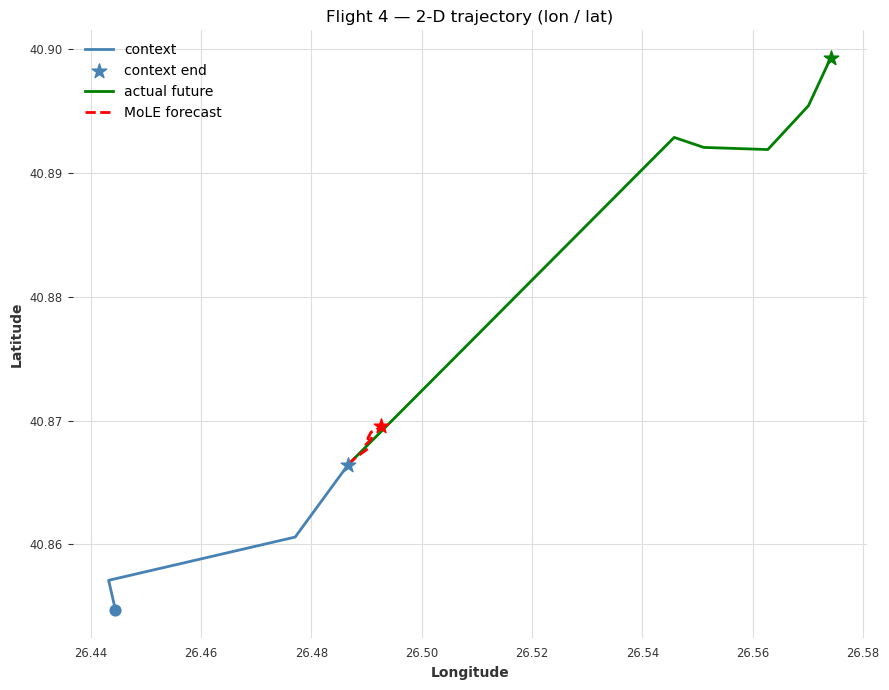

In [81]:
fig, ax = plt.subplots(figsize=(9, 7))

# Context path
ax.plot(ctx_orig[:, 0], ctx_orig[:, 1],
        color='steelblue', linewidth=2, label='context')
ax.scatter(ctx_orig[0,  0], ctx_orig[0,  1], color='steelblue', s=60, zorder=5)
ax.scatter(ctx_orig[-1, 0], ctx_orig[-1, 1], color='steelblue', s=120,
           marker='*', zorder=5, label='context end')

# Actual future — connected from last context point
ax.plot(
    [ctx_orig[-1, 0]] + list(act_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(act_orig[:, 1]),
    color='green', linewidth=2, label='actual future'
)
ax.scatter(act_orig[-1, 0], act_orig[-1, 1], color='green', s=120,
           marker='*', zorder=5)

# Forecast — connected from last context point
ax.plot(
    [ctx_orig[-1, 0]] + list(fct_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(fct_orig[:, 1]),
    color='red', linewidth=2, linestyle='--', label='MoLE forecast'
)
ax.scatter(fct_orig[-1, 0], fct_orig[-1, 1], color='red', s=120,
           marker='*', zorder=5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Flight {SAMPLE_IDX} — 2-D trajectory (lon / lat)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. 3-D trajectory plot (lon, lat, alt)

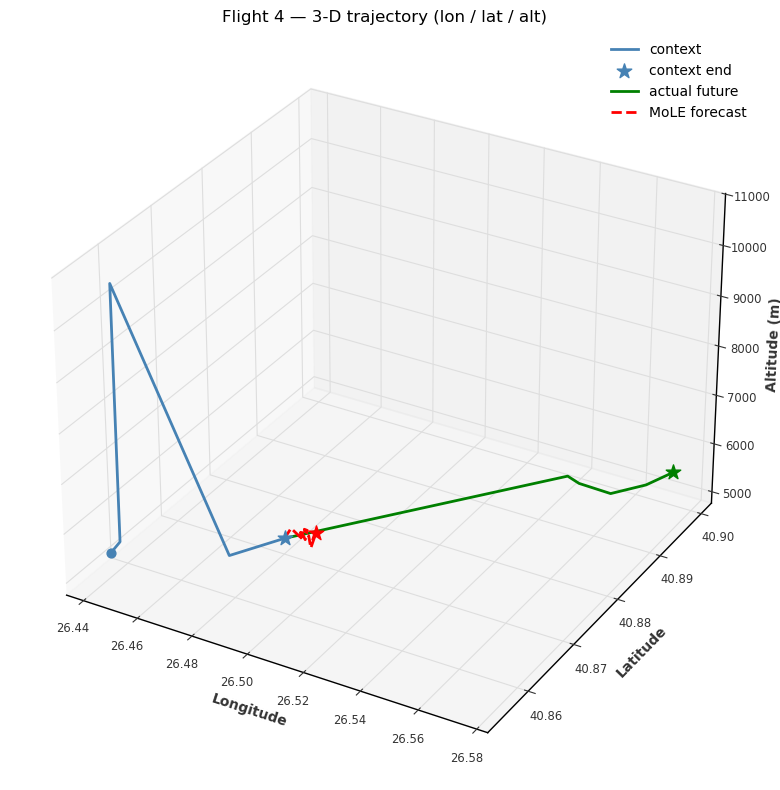

In [82]:
fig = plt.figure(figsize=(11, 8))
ax3 = fig.add_subplot(111, projection='3d')

# Context path
ax3.plot(ctx_orig[:, 0], ctx_orig[:, 1], ctx_orig[:, 2],
         color='steelblue', linewidth=2, label='context')
ax3.scatter(*ctx_orig[0],  color='steelblue', s=40, zorder=5)
ax3.scatter(*ctx_orig[-1], color='steelblue', s=120,
            marker='*', zorder=5, label='context end')

# Actual future — connect from last context point
bridge_act_lon = [ctx_orig[-1, 0]] + list(act_orig[:, 0])
bridge_act_lat = [ctx_orig[-1, 1]] + list(act_orig[:, 1])
bridge_act_alt = [ctx_orig[-1, 2]] + list(act_orig[:, 2])
ax3.plot(bridge_act_lon, bridge_act_lat, bridge_act_alt,
         color='green', linewidth=2, label='actual future')
ax3.scatter(*act_orig[-1], color='green', s=120, marker='*', zorder=5)

# Forecast — connect from last context point
bridge_fct_lon = [ctx_orig[-1, 0]] + list(fct_orig[:, 0])
bridge_fct_lat = [ctx_orig[-1, 1]] + list(fct_orig[:, 1])
bridge_fct_alt = [ctx_orig[-1, 2]] + list(fct_orig[:, 2])
ax3.plot(bridge_fct_lon, bridge_fct_lat, bridge_fct_alt,
         color='red', linewidth=2, linestyle='--', label='MoLE forecast')
ax3.scatter(*fct_orig[-1], color='red', s=120, marker='*', zorder=5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.set_zlabel('Altitude (m)')
ax3.set_title(f'Flight {SAMPLE_IDX} — 3-D trajectory (lon / lat / alt)')
ax3.legend()
plt.tight_layout()
plt.show()

## 12. Save model weights

In [84]:
import os
os.makedirs('saved_models', exist_ok=True)
save_path = os.path.join('saved_models', 'mole.pt')
torch.save({
    'state_dict': model.state_dict(),
    'configs': {k: getattr(configs, k) for k in dir(configs) if not k.startswith('_')},
}, save_path)
print(f'Model saved to {save_path}')


Model saved to saved_models/mole.pt
